# Baseline Model Evaluation: Pre-Fine-Tuning Performance

## Overview
This notebook establishes the **baseline performance** of a small language model on the Opinion Mining task **BEFORE** fine-tuning.

### Goals:
1. Evaluate zero-shot capability
2. Check JSON compliance
3. Measure baseline accuracy

This will be used to compare improvements after LoRA fine-tuning.

## Plan: Baseline Testing with First 20 Samples

**Summary**: The test data contains instruction-prompt pairs with ground-truth aspect-level annotations (term + polarity). Create a notebook implementation that: (1) loads and displays first 20 samples, (2) tests the base model on these 20 reviews, (3) compares predictions against ground-truth aspects, and (4) calculates baseline metrics.

### Steps

1. **Parse first 20 test samples** — In [00_baseline_evaluation.ipynb](E:\FCAI-HU\level4\semester2\nlu\Opinion-Mining-LLM\notebooks\00_baseline_evaluation.ipynb):
   - Load `test.jsonl` and extract first 20 records
   - Display sample structure: `input` (review), `output` (ground-truth aspects with term/polarity)
   - Show data characteristics (review length, aspect count distribution)

2. **Load base model without adapter** — Use `src/model_loader.load_model()` and `load_tokenizer()` with **no adapter path** (baseline only).

3. **Run zero-shot inference on 20 samples** — For each review in first 20:
   - Call `src/inference.generate_structured_output()` to get predictions
   - Log raw model output and extracted JSON
   - Catch any JSON parsing errors

4. **Validate prediction structure** — Use `src/utils.validate_prediction_structure()` to check JSON validity, count valid vs. invalid outputs.

5. **Compare predictions vs. ground-truth** — Map predicted aspects to ground-truth `term`/`polarity` and calculate:
   - JSON validity rate (%)
   - Aspect extraction precision/recall
   - Polarity accuracy for matched aspects

6. **Save baseline results** — Output metrics table and first 20 predictions to `results/baseline_evaluation.csv` for later comparison with fine-tuned model.

### Further Considerations

1. **Format mismatch** — Ground-truth uses `term`/`polarity`, but inference expects `feature`/`sentiment`. Should we adapt the comparison logic to handle both formats?

2. **Error handling** — If base model fails on JSON parsing for some samples, should we log these as invalid or skip them from metrics?


## 1. Setup: Imports and Configuration


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Opinion-Mining-LLM/src

/content/drive/MyDrive/Opinion-Mining-LLM/src


In [6]:
import sys
import json
import pandas as pd
import numpy as np
from pathlib import Path
from typing import Dict, List, Any, Tuple
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# Add src to path
# sys.path.insert(0, str(Path(".").resolve().parent / "src"))

from model_loader import load_model,load_tokenizer, DEFAULT_BASE_MODEL
from inference import generate_structured_output
from utils import validate_prediction_structure

# Configuration
BASE_MODEL_NAME = DEFAULT_BASE_MODEL
NUM_SAMPLES = 20
TEST_DATA_PATH = Path("../data/Labeled-data/test_labeled_v2.json")
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(exist_ok=True)

print(f"✓ Base Model: {BASE_MODEL_NAME}")
print(f"✓ Number of samples to test: {NUM_SAMPLES}")
print(f"✓ Test data path: {TEST_DATA_PATH}")


✓ Base Model: Qwen/Qwen2.5-1.5B-Instruct
✓ Number of samples to test: 20
✓ Test data path: ../data/Labeled-data/test_labeled_v2.json


## 2. Load and Inspect First 20 Test Samples


In [8]:
import json

# Load first 20 samples from test.jsonl
test_samples = []
with open(TEST_DATA_PATH, 'r', encoding='utf-8') as f:
    full_content = f.read()
    all_samples = json.loads(full_content)
    test_samples = all_samples[:NUM_SAMPLES]

print(f"Loaded {len(test_samples)} samples from test data\n")

# Display sample data structure
print("=" * 80)
print("SAMPLE DATA STRUCTURE (First Example)")
print("=" * 80)
sample_example = test_samples[0]
print(f"Keys in record: {sample_example.keys()}\n")
print(f"Input (Review): {sample_example['input']}\n")
print(f"Output (Ground-Truth): {sample_example['prediction']}\n")

Loaded 20 samples from test data

SAMPLE DATA STRUCTURE (First Example)
Keys in record: dict_keys(['input', 'prediction'])

Input (Review): Boot time is super fast, around anywhere from 35 seconds to 1 minute.

Output (Ground-Truth): {"domain":"electronics","aspects":[{"term":"Boot time","polarity":"positive"}]}



In [9]:
4# Analyze data characteristics
reviews = [s['input'] for s in test_samples]
ground_truth_outputs = [json.loads(s['prediction']) for s in test_samples]

# Extract statistics
review_lengths = [len(review.split()) for review in reviews]
aspect_counts = [len(gt.get('aspects', [])) for gt in ground_truth_outputs]

print("\n" + "=" * 80)
print("DATA CHARACTERISTICS")
print("=" * 80)
print(f"Number of samples: {len(test_samples)}")
print(f"Average review length: {np.mean(review_lengths):.1f} words")
print(f"Min review length: {min(review_lengths)} words")
print(f"Max review length: {max(review_lengths)} words")
print(f"Average aspects per review: {np.mean(aspect_counts):.2f}")
print(f"Samples with no aspects: {sum(1 for count in aspect_counts if count == 0)}")
print(f"Samples with 1+ aspects: {sum(1 for count in aspect_counts if count > 0)}")

# Show first 5 reviews and their ground-truth aspects
print("\n" + "=" * 80)
print("FIRST 5 REVIEWS AND GROUND-TRUTH ASPECTS")
print("=" * 80)
for idx in range(min(5, len(test_samples))):
    print(f"\n[Sample {idx+1}]")
    print(f"Review: {reviews[idx]}")
    aspects = ground_truth_outputs[idx].get('aspects', [])
    print(f"Ground-truth aspects: {aspects}")



DATA CHARACTERISTICS
Number of samples: 20
Average review length: 12.8 words
Min review length: 4 words
Max review length: 37 words
Average aspects per review: 1.70
Samples with no aspects: 0
Samples with 1+ aspects: 20

FIRST 5 REVIEWS AND GROUND-TRUTH ASPECTS

[Sample 1]
Review: Boot time is super fast, around anywhere from 35 seconds to 1 minute.
Ground-truth aspects: [{'term': 'Boot time', 'polarity': 'positive'}]

[Sample 2]
Review: tech support would not fix the problem unless I bought your plan for 150 plus.
Ground-truth aspects: [{'term': 'tech support', 'polarity': 'negative'}]

[Sample 3]
Review: but in resume this computer rocks!
Ground-truth aspects: [{'term': 'computer', 'polarity': 'positive'}]

[Sample 4]
Review: Set up was easy.
Ground-truth aspects: [{'term': 'Set up', 'polarity': 'positive'}]

[Sample 5]
Review: Did not enjoy the new Windows 8 and touchscreen functions.
Ground-truth aspects: [{'term': 'Windows 8', 'polarity': 'negative'}, {'term': 'touchscreen functi

## 3. Load Base Model (No Fine-tuning Adapter)


In [10]:
pip install -U bitsandbytes>=0.46.1

In [11]:
print("Loading base model and tokenizer...")
print(f"Model: {BASE_MODEL_NAME}")

# Load base model without LoRA adapter
tokenizer = load_tokenizer(base_model_name=BASE_MODEL_NAME)
model = load_model(base_model_name=BASE_MODEL_NAME, adapter_path=None, load_in_4bit=True)

print(f"✓ Model loaded successfully")
print(f"✓ Tokenizer loaded successfully")
print(f"✓ Model device: {model.device}")


Loading base model and tokenizer...
Model: Qwen/Qwen2.5-1.5B-Instruct


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

✓ Model loaded successfully
✓ Tokenizer loaded successfully
✓ Model device: cuda:0


## 4. Run Zero-Shot Inference on 20 Samples


In [13]:
print("Running zero-shot inference on 20 samples...\n")

predictions = []
errors = []
invalid_json_count = 0
valid_json_count = 0

for idx, sample in enumerate(test_samples):
    review = sample['input']
    ground_truth = json.loads(sample['prediction'])

    try:
        # Generate structured output using the model
        prediction = generate_structured_output(
            model=model,
            tokenizer=tokenizer,
            review_text=review,
            max_new_tokens=256
        )

        # Validate prediction structure
        is_valid = validate_prediction_structure(prediction)

        if is_valid:
            valid_json_count += 1
        else:
            invalid_json_count += 1

        predictions.append({
            'sample_idx': idx,
            'review': review,
            'prediction': prediction,
            'ground_truth': ground_truth,
            'json_valid': is_valid,
            'error': None
        })

        print(f"[{idx+1:2d}/{NUM_SAMPLES}] ✓ JSON Valid: {is_valid}")

    except Exception as e:
        invalid_json_count += 1
        error_msg = str(e)[:100]

        predictions.append({
            'sample_idx': idx,
            'review': review,
            'prediction': None,
            'ground_truth': ground_truth,
            'json_valid': False,
            'error': error_msg
        })

        print(f"[{idx+1:2d}/{NUM_SAMPLES}] ✗ Error: {error_msg}")

print(f"\n{'='*80}")
print("INFERENCE SUMMARY")
print(f"{'='*80}")
print(f"Total samples: {len(predictions)}")
print(f"Valid JSON: {valid_json_count} ({100*valid_json_count/len(predictions):.1f}%)")
print(f"Invalid JSON: {invalid_json_count} ({100*invalid_json_count/len(predictions):.1f}%)")


Running zero-shot inference on 20 samples...

[ 1/20] ✗ Error: Extra data: line 5 column 4 (char 90)
[ 2/20] ✗ Error: No JSON object found in model output.
[ 3/20] ✗ Error: Expecting ',' delimiter: line 19 column 6 (char 705)
[ 4/20] ✗ Error: No JSON object found in model output.
[ 5/20] ✓ JSON Valid: True
[ 6/20] ✗ Error: No JSON object found in model output.
[ 7/20] ✗ Error: No JSON object found in model output.
[ 8/20] ✓ JSON Valid: True
[ 9/20] ✗ Error: No JSON object found in model output.
[10/20] ✗ Error: Expecting ',' delimiter: line 14 column 6 (char 624)
[11/20] ✗ Error: No JSON object found in model output.
[12/20] ✗ Error: Extra data: line 1 column 59 (char 58)
[13/20] ✗ Error: Expecting ',' delimiter: line 19 column 6 (char 738)
[14/20] ✗ Error: No JSON object found in model output.
[15/20] ✗ Error: No JSON object found in model output.
[16/20] ✗ Error: No JSON object found in model output.
[17/20] ✗ Error: Extra data: line 5 column 4 (char 89)
[18/20] ✗ Error: Expecting ',

## 5. Evaluate Predictions Against Ground-Truth


In [19]:
# Helper function to extract aspects from predictions and ground-truth
def extract_aspect_terms(aspects_list):
    """Extract aspect terms from a list of aspect dictionaries"""
    terms = set()
    for aspect in aspects_list:
        if isinstance(aspect, dict):
            # Handle both formats: 'feature' and 'term'
            term = aspect.get('feature') or aspect.get('term')
            if term:
                terms.add(term.lower())
    return terms

def extract_aspect_polarity_dict(aspects_list):
    """Extract aspect terms and their polarities"""
    polarity_dict = {}
    for aspect in aspects_list:
        if isinstance(aspect, dict):
            term = aspect.get('feature') or aspect.get('term')
            polarity = aspect.get('sentiment') or aspect.get('polarity')
            if term:
                polarity_dict[term.lower()] = polarity
    return polarity_dict

# Calculate metrics
total_aspects_gt = 0
total_aspects_pred = 0
correct_polarity = 0
matched_aspects = 0

aspect_precision_list = []
aspect_recall_list = []

print("\n" + "=" * 80)
print("DETAILED PREDICTION ANALYSIS")
print("=" * 80 + "\n")

for pred_result in predictions:
    if not pred_result['json_valid'] or pred_result['prediction'] is None:
        print(f"[Sample {pred_result['sample_idx']+1}] INVALID JSON - Skipping aspect comparison")
        continue

    gt_aspects = pred_result['ground_truth'].get('aspects', [])
    pred_aspects = pred_result['prediction'].get('aspects', [])

    total_aspects_gt += len(gt_aspects)
    total_aspects_pred += len(pred_aspects)

    gt_terms = extract_aspect_terms(gt_aspects)
    pred_terms = extract_aspect_terms(pred_aspects)

    # Calculate precision and recall for this sample
    if len(pred_terms) > 0:
        sample_precision = len(gt_terms & pred_terms) / len(pred_terms)
    else:
        sample_precision = 1.0 if len(gt_terms) == 0 else 0.0

    if len(gt_terms) > 0:
        sample_recall = len(gt_terms & pred_terms) / len(gt_terms)
    else:
        sample_recall = 1.0 if len(pred_terms) == 0 else 0.0

    aspect_precision_list.append(sample_precision)
    aspect_recall_list.append(sample_recall)

    # Check polarity accuracy for matched aspects
    gt_polarity_dict = extract_aspect_polarity_dict(gt_aspects)
    pred_polarity_dict = extract_aspect_polarity_dict(pred_aspects)

    for term in gt_terms & pred_terms:
        matched_aspects += 1
        if gt_polarity_dict.get(term) == pred_polarity_dict.get(term):
            correct_polarity += 1

    print(f"[Sample {pred_result['sample_idx']+1}]")
    print(f"  Review: {pred_result['review'][:60]}...")
    print(f"  Ground-truth aspects: {list(gt_terms)}")
    print(f"  Predicted aspects: {list(pred_terms)}")
    print(f"  Matched: {list(gt_terms & pred_terms)}")
    print()



DETAILED PREDICTION ANALYSIS

[Sample 1] INVALID JSON - Skipping aspect comparison
[Sample 2] INVALID JSON - Skipping aspect comparison
[Sample 3] INVALID JSON - Skipping aspect comparison
[Sample 4] INVALID JSON - Skipping aspect comparison
[Sample 5]
  Review: Did not enjoy the new Windows 8 and touchscreen functions....
  Ground-truth aspects: ['windows 8', 'touchscreen functions']
  Predicted aspects: ['keyboard', 'touchscreen']
  Matched: []

[Sample 6] INVALID JSON - Skipping aspect comparison
[Sample 7] INVALID JSON - Skipping aspect comparison
[Sample 8]
  Review: excellent in every way....
  Ground-truth aspects: ['excellent']
  Predicted aspects: ['packaging', 'quality', 'delivery', 'price']
  Matched: []

[Sample 9] INVALID JSON - Skipping aspect comparison
[Sample 10] INVALID JSON - Skipping aspect comparison
[Sample 11] INVALID JSON - Skipping aspect comparison
[Sample 12] INVALID JSON - Skipping aspect comparison
[Sample 13] INVALID JSON - Skipping aspect comparison
[Sam

In [15]:
# Calculate aggregate metrics
avg_precision = np.mean(aspect_precision_list) if aspect_precision_list else 0
avg_recall = np.mean(aspect_recall_list) if aspect_recall_list else 0

if matched_aspects > 0:
    polarity_accuracy = correct_polarity / matched_aspects
else:
    polarity_accuracy = 0

# Calculate F1-score
if avg_precision + avg_recall > 0:
    f1_score = 2 * (avg_precision * avg_recall) / (avg_precision + avg_recall)
else:
    f1_score = 0

print("\n" + "=" * 80)
print("BASELINE METRICS SUMMARY")
print("=" * 80)
print(f"\nJSON Validity:")
print(f"  Valid JSON: {valid_json_count}/{len(predictions)} ({100*valid_json_count/len(predictions):.1f}%)")

print(f"\nAspect Extraction:")
print(f"  Total ground-truth aspects: {total_aspects_gt}")
print(f"  Total predicted aspects: {total_aspects_pred}")
print(f"  Average Precision: {avg_precision:.3f}")
print(f"  Average Recall: {avg_recall:.3f}")
print(f"  F1-Score: {f1_score:.3f}")

if matched_aspects > 0:
    print(f"\nPolarity Classification (for matched aspects):")
    print(f"  Matched aspects: {matched_aspects}")
    print(f"  Correct polarity: {correct_polarity}/{matched_aspects} ({100*polarity_accuracy:.1f}%)")



BASELINE METRICS SUMMARY

JSON Validity:
  Valid JSON: 3/20 (15.0%)

Aspect Extraction:
  Total ground-truth aspects: 6
  Total predicted aspects: 10
  Average Precision: 0.000
  Average Recall: 0.000
  F1-Score: 0.000


## 6. Save Baseline Results


In [20]:
# Create results dataframe
results_data = []

for pred_result in predictions:
    results_data.append({
        'sample_idx': pred_result['sample_idx'],
        'review': pred_result['review'],
        'json_valid': pred_result['json_valid'],
        'error': pred_result['error'],
        'ground_truth_aspects': json.dumps(pred_result['ground_truth'].get('aspects', [])),
        'predicted_aspects': json.dumps(pred_result['prediction'].get('aspects', []) if pred_result['prediction'] else []),
    })

results_df = pd.DataFrame(results_data)
results_csv_path = RESULTS_DIR / "baseline_evaluation.csv"
results_df.to_csv(results_csv_path, index=False)

print(f"✓ Results saved to: {results_csv_path}\n")
print(results_df[['sample_idx', 'json_valid', 'error']].to_string())


✓ Results saved to: ../results/baseline_evaluation.csv

    sample_idx  json_valid                                                 error
0            0       False                 Extra data: line 5 column 4 (char 90)
1            1       False                 No JSON object found in model output.
2            2       False  Expecting ',' delimiter: line 19 column 6 (char 705)
3            3       False                 No JSON object found in model output.
4            4        True                                                  None
5            5       False                 No JSON object found in model output.
6            6       False                 No JSON object found in model output.
7            7        True                                                  None
8            8       False                 No JSON object found in model output.
9            9       False  Expecting ',' delimiter: line 14 column 6 (char 624)
10          10       False                 No JSON ob

In [21]:
# Save detailed metrics to a summary file
metrics_summary = {
    'model': BASE_MODEL_NAME,
    'num_samples': len(predictions),
    'json_validity_rate': valid_json_count / len(predictions),
    'average_precision': float(avg_precision),
    'average_recall': float(avg_recall),
    'f1_score': float(f1_score),
    'polarity_accuracy': float(polarity_accuracy) if matched_aspects > 0 else 0,
    'matched_aspects': matched_aspects,
    'total_ground_truth_aspects': total_aspects_gt,
    'total_predicted_aspects': total_aspects_pred,
}

metrics_json_path = RESULTS_DIR / "baseline_metrics.json"
with open(metrics_json_path, 'w', encoding='utf-8') as f:
    json.dump(metrics_summary, f, indent=2)

print(f"\n✓ Metrics saved to: {metrics_json_path}")



✓ Metrics saved to: ../results/baseline_metrics.json


## 7. Visualization



✓ Visualization saved to: ../results/baseline_evaluation_plots.png


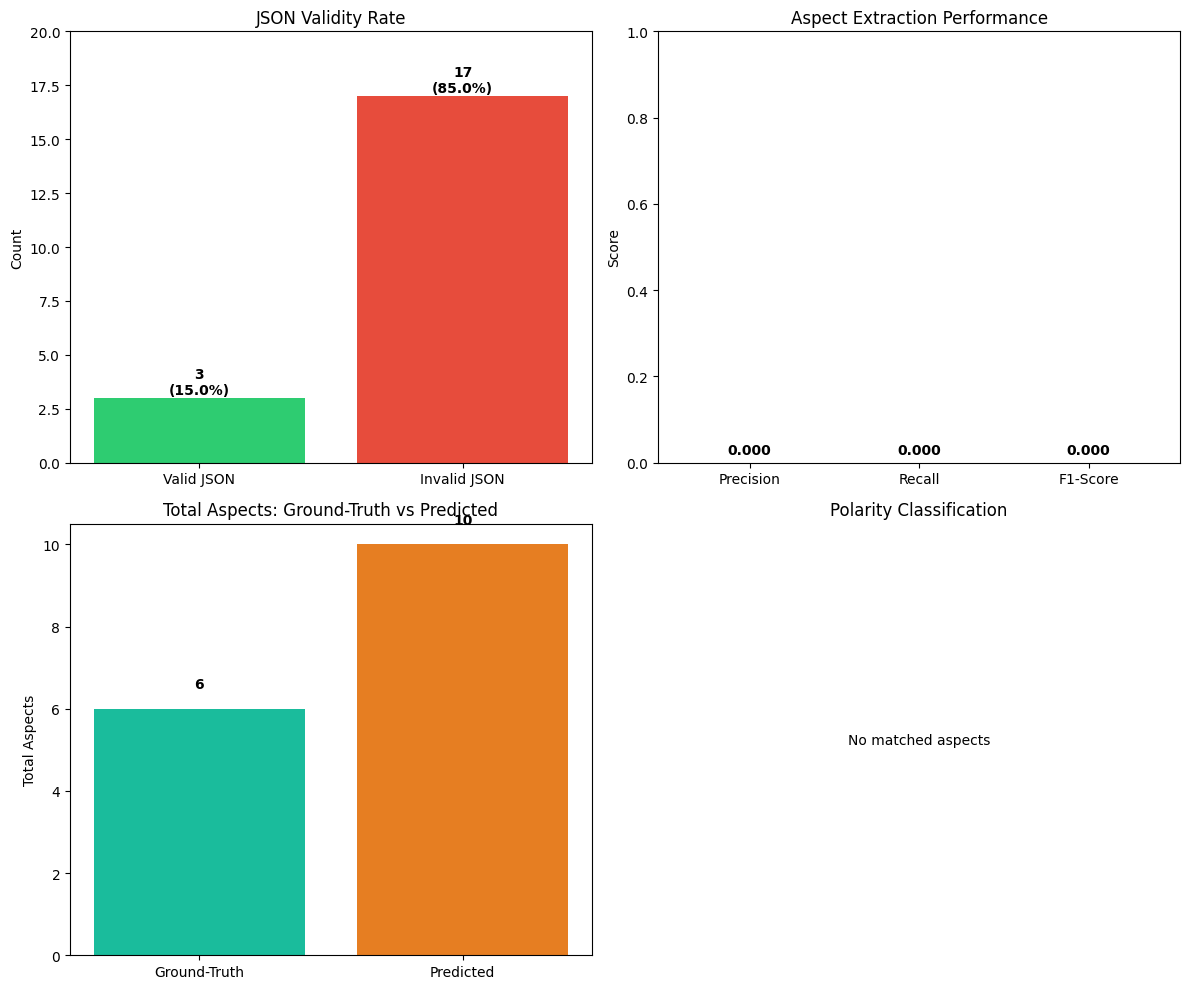


BASELINE EVALUATION COMPLETE

This baseline will be compared with post-fine-tuning performance in later notebooks.


In [22]:
# Create visualization of baseline metrics
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: JSON Validity
ax1 = axes[0, 0]
validity_counts = [valid_json_count, invalid_json_count]
labels = ['Valid JSON', 'Invalid JSON']
colors = ['#2ecc71', '#e74c3c']
ax1.bar(labels, validity_counts, color=colors)
ax1.set_ylabel('Count')
ax1.set_title('JSON Validity Rate')
ax1.set_ylim(0, len(predictions))
for i, v in enumerate(validity_counts):
    ax1.text(i, v + 0.2, f'{v}\n({100*v/len(predictions):.1f}%)', ha='center', fontweight='bold')

# Plot 2: Aspect Extraction Metrics
ax2 = axes[0, 1]
metrics = ['Precision', 'Recall', 'F1-Score']
values = [avg_precision, avg_recall, f1_score]
colors_metrics = ['#3498db', '#9b59b6', '#f39c12']
ax2.bar(metrics, values, color=colors_metrics)
ax2.set_ylabel('Score')
ax2.set_title('Aspect Extraction Performance')
ax2.set_ylim(0, 1)
for i, v in enumerate(values):
    ax2.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Plot 3: Aspect Count Comparison
ax3 = axes[1, 0]
aspect_counts_comparison = [total_aspects_gt, total_aspects_pred]
labels_aspects = ['Ground-Truth', 'Predicted']
ax3.bar(labels_aspects, aspect_counts_comparison, color=['#1abc9c', '#e67e22'])
ax3.set_ylabel('Total Aspects')
ax3.set_title('Total Aspects: Ground-Truth vs Predicted')
for i, v in enumerate(aspect_counts_comparison):
    ax3.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Plot 4: Polarity Accuracy
ax4 = axes[1, 1]
if matched_aspects > 0:
    polarity_correct = [correct_polarity, matched_aspects - correct_polarity]
    labels_polarity = ['Correct', 'Incorrect']
    colors_polarity = ['#27ae60', '#c0392b']
    ax4.bar(labels_polarity, polarity_correct, color=colors_polarity)
    ax4.set_ylabel('Count')
    ax4.set_title(f'Polarity Classification (Matched Aspects)\nAccuracy: {100*polarity_accuracy:.1f}%')
    for i, v in enumerate(polarity_correct):
        ax4.text(i, v + 0.2, str(v), ha='center', fontweight='bold')
else:
    ax4.text(0.5, 0.5, 'No matched aspects', ha='center', va='center', transform=ax4.transAxes)
    ax4.set_title('Polarity Classification')
    ax4.axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / "baseline_evaluation_plots.png", dpi=300, bbox_inches='tight')
print(f"\n✓ Visualization saved to: {RESULTS_DIR / 'baseline_evaluation_plots.png'}")
plt.show()

print("\n" + "=" * 80)
print("BASELINE EVALUATION COMPLETE")
print("=" * 80)
print(f"\nThis baseline will be compared with post-fine-tuning performance in later notebooks.")

